In [1]:
import sys
from pathlib import Path
import os

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml

if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Set the environment variables from the file <root_dir>/.env
from mlfs import config
if os.path.exists(f"{root_dir}/.env"):
    settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /Users/leahhh/Desktop/ID2223_scalable/Project_SML
HopsworksSettings initialized!


In [2]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
import hopsworks
from mlfs.airquality import util
import json

import warnings
warnings.filterwarnings("ignore")

In [12]:
today = datetime.now()
tomorrow = today + timedelta(days = 1)
today

datetime.datetime(2026, 1, 3, 17, 19, 29, 770674)

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [3]:
project = hopsworks.login()
fs = project.get_feature_store() 
secrets = hopsworks.get_secrets_api()

# Get configuration from Hopsworks secrets
config_str = secrets.get_secret("EXCHANGE_RATE_CONFIG").value
config_dict = json.loads(config_str)

currency_pair = config_dict['currency_pair']
base_currency = config_dict['base_currency']
quote_currency = config_dict['quote_currency']
countries = config_dict['countries']

print(f"Currency Pair: {currency_pair}")
print(f"Base Currency: {base_currency}")
print(f"Quote Currency: {quote_currency}")
print(f"Countries: {countries}")

2026-01-03 17:14:21,612 INFO: Initializing external client
2026-01-03 17:14:21,614 INFO: Base URL: https://c.app.hopsworks.ai:443


2026-01-03 17:14:23,559 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1286353
Currency Pair: EUR_SEK
Base Currency: EUR
Quote Currency: SEK
Countries: ['EU', 'Sweden']


## <span style="color:#ff5f27;">🪝 Download models from Model Registry</span>

**Note:** We will download both the baseline model (`air_quality_xgboost_model`) and the improved model with lagged features (`air_quality_xgboost_model_lagged`) to compare their predictions.

In [6]:
mr = project.get_model_registry()

baseline_model = mr.get_model(
    name="xgboost_model",
    version=1,
)

lagged_model = mr.get_model(
    name="xgboost_model_lagged",
    version=1,
)

saved_baseline_model_dir = baseline_model.download()
saved_lagged_model_dir = lagged_model.download()

Downloading: 0.000%|          | 0/223018 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/23518 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/14098 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/418272 elapsed<00:00 remaining<?

In [7]:
retrieved_xgboost_baseline = XGBRegressor()
retrieved_xgboost_baseline.load_model(saved_baseline_model_dir + "/model.json")

retrieved_xgboost_lagged = XGBRegressor()
retrieved_xgboost_lagged.load_model(saved_lagged_model_dir + "/model_lagged.json")

print("Baseline model loaded")
print("Lagged model loaded")

Baseline model loaded
Lagged model loaded


## <span style="color:#ff5f27;">✨ Get Exchange Rate Features with Feature View   </span>



In [18]:
# Retrieve feature groups
exchange_rate_fg = fs.get_feature_group(
    name='exchange_rate',
    version=1,
)
inflation_fg = fs.get_feature_group(
    name='inflation',
    version=2,
)
interest_rate_fg = fs.get_feature_group(
    name='interest_rate',
    version=3,
)

exchange_rate_data = exchange_rate_fg.read()
inflation_data = inflation_fg.read()
interest_data = interest_rate_fg.read()

batch_data = exchange_rate_data.merge(inflation_data, on='date', how='left')
batch_data = batch_data.merge(interest_data, on='date', how='left')

batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.48s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.74s) 
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.05s) 


,date,eur_sek_rate,eu_inflation_rate,sweden_inflation_rate,sweden_interest_rate
0,2023-01-23 00:00:00+00:00,11.1183,NaN,NaN,2.394
1,2025-01-07 00:00:00+00:00,11.4750,NaN,NaN,2.626
2,2025-10-03 00:00:00+00:00,11.0030,NaN,NaN,1.648
3,2019-09-24 00:00:00+00:00,10.6763,NaN,NaN,NaN
4,2018-06-14 00:00:00+00:00,10.1600,NaN,NaN,NaN
...,...,...,...,...,...
2635,2022-02-22 00:00:00+00:00,10.5996,NaN,NaN,-0.100
2636,2023-12-12 00:00:00+00:00,11.2815,NaN,NaN,3.898
2637,2024-07-22 00:00:00+00:00,11.6295,NaN,NaN,3.646
2638,2019-10-09 00:00:00+00:00,10.9173,NaN,NaN,NaN


### <span style="color:#ff5f27;">Adding Lagged Features to Batch Data</span>


In [50]:

exchange_rate_data = exchange_rate_data[['date', 'eur_sek_rate']].sort_values('date').reset_index(drop=True)
exchange_rate_data['date'] = pd.to_datetime(exchange_rate_data['date']).dt.tz_localize(None)

LAGS = [1, 3, 5, 10, 15]
for lag in LAGS:
    exchange_rate_data[f'eur_sek_lag_{lag}d'] = (
        exchange_rate_data['eur_sek_rate'].shift(lag))

lag_means = {lag: exchange_rate_data[f'eur_sek_lag_{lag}d'].mean() for lag in LAGS}

batch_data_with_date = batch_data.copy()
batch_data_with_date['date'] = pd.to_datetime(batch_data_with_date['date']).dt.tz_localize(None)
batch_data_lagged = pd.merge(batch_data_with_date,
    exchange_rate_data[['date'] + [f'eur_sek_lag_{lag}d' for lag in LAGS]],
    on='date', how='left')

for lag in LAGS:
    col = f'eur_sek_lag_{lag}d'
    batch_data_lagged[col] = batch_data_lagged[col].fillna(lag_means[lag])

batch_data_lagged

,date,eur_sek_rate,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,predicted_exchange_rate,currency_pair,base_currency,quote_currency,days_before_forecast_day,eur_sek_lag_1d,eur_sek_lag_3d,eur_sek_lag_5d,eur_sek_lag_10d,eur_sek_lag_15d
0,2015-08-28,9.4953,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,999,10.476721,10.476398,10.476115,10.47522,10.47424
1,2015-08-31,9.5032,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,1529,9.495300,10.476398,10.476115,10.47522,10.47424
2,2015-09-01,9.4954,0.1,0.9,NaN,9.482051,EUR_SEK,EUR,SEK,290,9.503200,10.476398,10.476115,10.47522,10.47424
3,2015-09-02,9.4968,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,383,9.495400,9.495300,10.476115,10.47522,10.47424
4,2015-09-03,9.3907,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,1219,9.496800,9.503200,10.476115,10.47522,10.47424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2025-12-10,10.8580,NaN,NaN,1.634,10.932815,EUR_SEK,EUR,SEK,191,10.901500,10.959000,10.955000,11.03450,10.99200
2636,2025-12-11,10.8450,NaN,NaN,1.649,10.844972,EUR_SEK,EUR,SEK,423,10.858000,10.949500,10.967000,10.99450,10.99950
2637,2025-12-12,10.8865,NaN,NaN,1.643,10.890105,EUR_SEK,EUR,SEK,376,10.845000,10.901500,10.959000,10.96950,11.02600
2638,2025-12-15,10.9155,NaN,NaN,1.642,10.888358,EUR_SEK,EUR,SEK,1315,10.886500,10.858000,10.949500,10.96300,11.00600


In [25]:
batch_data = batch_data.rename(columns={
    'eu_inflation_rate': 'inflation_eu_inflation_rate',
    'sweden_inflation_rate': 'inflation_sweden_inflation_rate',
    'sweden_interest_rate': 'interest_rate_sweden_interest_rate'
})

batch_data['predicted_exchange_rate'] = retrieved_xgboost_baseline.predict(
    batch_data[['inflation_eu_inflation_rate', 'inflation_sweden_inflation_rate', 'interest_rate_sweden_interest_rate']])

batch_data

,date,eur_sek_rate,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,predicted_exchange_rate
0,2023-01-23 00:00:00+00:00,11.1183,NaN,NaN,2.394,11.208635
1,2025-01-07 00:00:00+00:00,11.4750,NaN,NaN,2.626,11.182101
2,2025-10-03 00:00:00+00:00,11.0030,NaN,NaN,1.648,10.844972
3,2019-09-24 00:00:00+00:00,10.6763,NaN,NaN,NaN,10.053867
4,2018-06-14 00:00:00+00:00,10.1600,NaN,NaN,NaN,10.053867
...,...,...,...,...,...,...
2635,2022-02-22 00:00:00+00:00,10.5996,NaN,NaN,-0.100,10.451633
2636,2023-12-12 00:00:00+00:00,11.2815,NaN,NaN,3.898,11.386781
2637,2024-07-22 00:00:00+00:00,11.6295,NaN,NaN,3.646,11.386781
2638,2019-10-09 00:00:00+00:00,10.9173,NaN,NaN,NaN,10.053867


In [51]:
batch_data_lagged = batch_data_lagged.rename(columns={
    'eu_inflation_rate': 'inflation_eu_inflation_rate',
    'sweden_inflation_rate': 'inflation_sweden_inflation_rate',
    'sweden_interest_rate': 'interest_rate_sweden_interest_rate'
})

batch_data_lagged['predicted_exchange_rate'] = retrieved_xgboost_lagged.predict(
    batch_data_lagged[[
    'inflation_eu_inflation_rate',
    'inflation_sweden_inflation_rate',
    'interest_rate_sweden_interest_rate',
    'eur_sek_lag_1d',
    'eur_sek_lag_3d',
    'eur_sek_lag_5d',
    'eur_sek_lag_10d',
    'eur_sek_lag_15d']])

batch_data_lagged

,date,eur_sek_rate,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,predicted_exchange_rate,currency_pair,base_currency,quote_currency,days_before_forecast_day,eur_sek_lag_1d,eur_sek_lag_3d,eur_sek_lag_5d,eur_sek_lag_10d,eur_sek_lag_15d
0,2015-08-28,9.4953,NaN,NaN,NaN,10.483472,EUR_SEK,EUR,SEK,999,10.476721,10.476398,10.476115,10.47522,10.47424
1,2015-08-31,9.5032,NaN,NaN,NaN,9.524911,EUR_SEK,EUR,SEK,1529,9.495300,10.476398,10.476115,10.47522,10.47424
2,2015-09-01,9.4954,0.1,0.9,NaN,9.523546,EUR_SEK,EUR,SEK,290,9.503200,10.476398,10.476115,10.47522,10.47424
3,2015-09-02,9.4968,NaN,NaN,NaN,9.506970,EUR_SEK,EUR,SEK,383,9.495400,9.495300,10.476115,10.47522,10.47424
4,2015-09-03,9.3907,NaN,NaN,NaN,9.468027,EUR_SEK,EUR,SEK,1219,9.496800,9.503200,10.476115,10.47522,10.47424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2025-12-10,10.8580,NaN,NaN,1.634,10.891447,EUR_SEK,EUR,SEK,191,10.901500,10.959000,10.955000,11.03450,10.99200
2636,2025-12-11,10.8450,NaN,NaN,1.649,10.904975,EUR_SEK,EUR,SEK,423,10.858000,10.949500,10.967000,10.99450,10.99950
2637,2025-12-12,10.8865,NaN,NaN,1.643,10.915365,EUR_SEK,EUR,SEK,376,10.845000,10.901500,10.959000,10.96950,11.02600
2638,2025-12-15,10.9155,NaN,NaN,1.642,10.894406,EUR_SEK,EUR,SEK,1315,10.886500,10.858000,10.949500,10.96300,11.00600


### <span style="color:#ff5f27;">💾 Saving the predictions (for monitoring) to a Feature Group</span>

In [29]:
batch_data['currency_pair'] = currency_pair
batch_data['base_currency'] = base_currency
batch_data['quote_currency'] = quote_currency
# batch_data['countries'] = countries
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data['days_before_forecast_day'] = range(1, len(batch_data) + 1)
batch_data = batch_data.sort_values(by=['date'])
batch_data

,date,eur_sek_rate,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,predicted_exchange_rate,currency_pair,base_currency,quote_currency,days_before_forecast_day
998,2015-08-28 00:00:00+00:00,9.4953,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,999
1528,2015-08-31 00:00:00+00:00,9.5032,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,1529
289,2015-09-01 00:00:00+00:00,9.4954,0.1,0.9,NaN,9.482051,EUR_SEK,EUR,SEK,290
382,2015-09-02 00:00:00+00:00,9.4968,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,383
1218,2015-09-03 00:00:00+00:00,9.3907,NaN,NaN,NaN,10.053867,EUR_SEK,EUR,SEK,1219
...,...,...,...,...,...,...,...,...,...,...
190,2025-12-10 00:00:00+00:00,10.8580,NaN,NaN,1.634,10.932815,EUR_SEK,EUR,SEK,191
422,2025-12-11 00:00:00+00:00,10.8450,NaN,NaN,1.649,10.844972,EUR_SEK,EUR,SEK,423
375,2025-12-12 00:00:00+00:00,10.8865,NaN,NaN,1.643,10.890105,EUR_SEK,EUR,SEK,376
1314,2025-12-15 00:00:00+00:00,10.9155,NaN,NaN,1.642,10.888358,EUR_SEK,EUR,SEK,1315


In [30]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 998 to 1388
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype                  
---  ------                              --------------  -----                  
 0   date                                2640 non-null   datetime64[us, Etc/UTC]
 1   eur_sek_rate                        2640 non-null   float32                
 2   inflation_eu_inflation_rate         74 non-null     float32                
 3   inflation_sweden_inflation_rate     74 non-null     float32                
 4   interest_rate_sweden_interest_rate  1083 non-null   float32                
 5   predicted_exchange_rate             2640 non-null   float32                
 6   currency_pair                       2640 non-null   object                 
 7   base_currency                       2640 non-null   object                 
 8   quote_currency                      2640 non-null   object                 
 9   

### Create Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

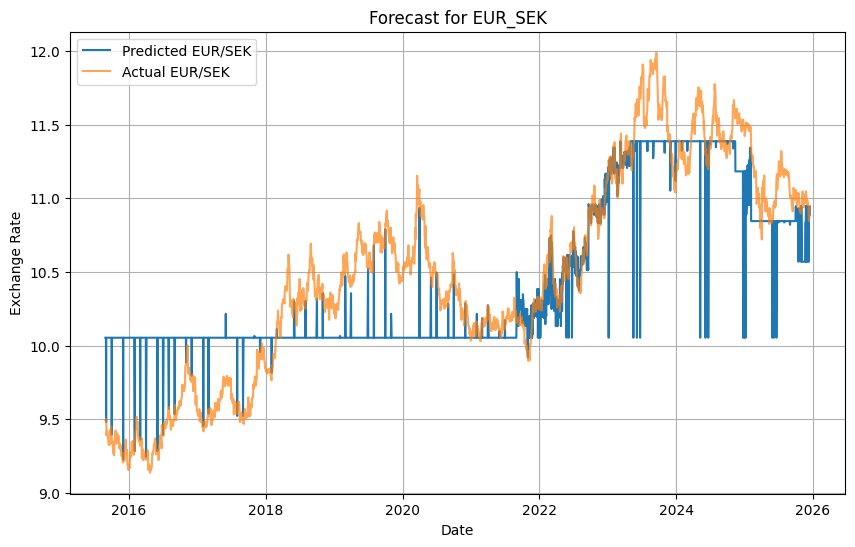

<Figure size 640x480 with 0 Axes>

In [66]:

plt.figure(figsize=(10,6))
plt.plot(batch_data['date'], batch_data['predicted_exchange_rate'], label='Predicted EUR/SEK')
plt.plot(batch_data['date'], batch_data['eur_sek_rate'], label='Actual EUR/SEK', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title(f'Forecast for {currency_pair}')
plt.legend()
plt.grid(True)
plt.show()

plt.savefig(f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_forecast.png")


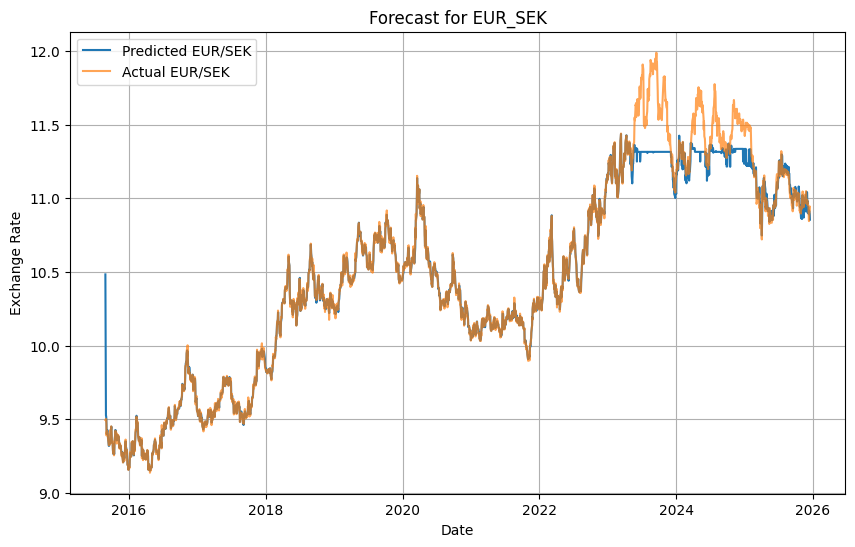

<Figure size 640x480 with 0 Axes>

In [67]:

plt.figure(figsize=(10,6))
plt.plot(batch_data_lagged['date'], batch_data_lagged['predicted_exchange_rate'], label='Predicted EUR/SEK')
plt.plot(batch_data_lagged['date'], batch_data_lagged['eur_sek_rate'], label='Actual EUR/SEK', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title(f'Forecast for {currency_pair}')
plt.legend()
plt.grid(True)
plt.show()

plt.savefig(f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_forecast_lagged.png")


In [44]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='currency_predictions',
    description='EU-SEK Exchange Rate Prediction Monitoring',
    version=1,
    primary_key=['currency_pair','base_currency','quote_currency','days_before_forecast_day'],
    event_time="date"
)

In [45]:
monitor_fg.insert(batch_data, wait=True)

Feature Group created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1286353/fs/1273974/fg/1898827


Uploading Dataframe: 100.00% |██████████| Rows 2640/2640 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: currency_predictions_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1286353/jobs/named/currency_predictions_1_offline_fg_materialization/executions
2026-01-03 17:51:32,989 INFO: Waiting for execution to finish. Current state: INITIALIZING. Final status: UNDEFINED
2026-01-03 17:51:36,192 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2026-01-03 17:53:49,040 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2026-01-03 17:53:49,230 INFO: Waiting for log aggregation to finish.
2026-01-03 17:54:15,301 INFO: Execution finished successfully.


(Job('currency_predictions_1_offline_fg_materialization', 'SPARK'), None)

In [53]:
# We will create a hindcast chart for  only the forecasts made 1 day beforehand
monitoring_df = monitor_fg.filter(monitor_fg.days_before_forecast_day == 1).read()
monitoring_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.17s) 


,date,eur_sek_rate,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,predicted_exchange_rate,currency_pair,base_currency,quote_currency,days_before_forecast_day
0,2023-01-23 00:00:00+00:00,11.1183,NaN,NaN,2.394,11.208635,EUR_SEK,EUR,SEK,1


In [55]:
exchange_rate_fg = fs.get_feature_group(name='exchange_rate', version=1)
exchange_rate_df = exchange_rate_fg.read()
exchange_rate_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.70s) 


,date,eur_sek_rate
0,2023-01-23 00:00:00+00:00,11.1183
1,2025-01-07 00:00:00+00:00,11.4750
2,2025-10-03 00:00:00+00:00,11.0030
3,2019-09-24 00:00:00+00:00,10.6763
4,2018-06-14 00:00:00+00:00,10.1600
...,...,...
2635,2022-02-22 00:00:00+00:00,10.5996
2636,2023-12-12 00:00:00+00:00,11.2815
2637,2024-07-22 00:00:00+00:00,11.6295
2638,2019-10-09 00:00:00+00:00,10.9173


In [58]:
outcome_df = exchange_rate_df[['date', 'eur_sek_rate']]
preds_df =  monitoring_df[['date', 'predicted_exchange_rate']]

hindcast_df = pd.merge(preds_df, outcome_df, on="date")
hindcast_df = hindcast_df.sort_values(by=['date'])

# If there are no outcomes for predictions yet, generate some predictions/outcomes from existing data
if len(hindcast_df) == 0:
    hindcast_df = util.backfill_predictions_for_monitoring(exchange_rate_fg, exchange_rate_df, monitor_fg, retrieved_xgboost_lagged)
hindcast_df

,date,predicted_exchange_rate,eur_sek_rate
0,2023-01-23 00:00:00+00:00,11.208635,11.1183


### Plot the Hindcast comparing predicted with forecasted values (1-day prior forecast)

__This graph will be empty to begin with - this is normal.__

After a few days of predictions and observations, you will get data points in this graph.

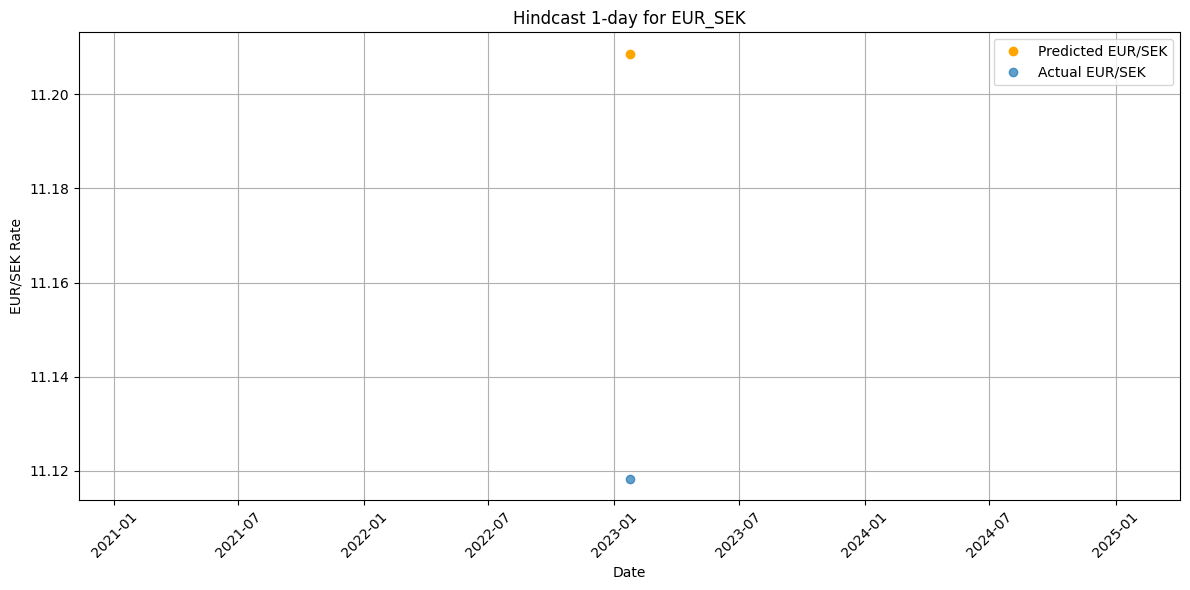

<Figure size 640x480 with 0 Axes>

In [68]:
plt.figure(figsize=(12,6))
plt.plot(hindcast_df['date'], hindcast_df['predicted_exchange_rate'], 'o', label='Predicted EUR/SEK', color='orange')
plt.plot(hindcast_df['date'], hindcast_df['eur_sek_rate'], 'o', label='Actual EUR/SEK', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('EUR/SEK Rate')
plt.title(f'Hindcast 1-day for {currency_pair}')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig(f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_hindcast_1day.png")


### Upload the prediction and hindcast dashboards (png files) to Hopsworks


In [71]:
forecast_file_path = f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_forecast.png"
forecast_lagged_file_path = f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_forecast_lagged.png"
hindcast_file_path = f"{root_dir}/docs/exchange-rate/assets/img/{currency_pair}_hindcast_1day.png"

dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/exchange_rate") == False:
    dataset_api.mkdir("Resources/exchange_rate")

dataset_api.upload(forecast_file_path,
    f"Resources/exchange_rate/{base_currency}_{quote_currency}_{str_today}_forecast.png",
    overwrite=True)
dataset_api.upload(forecast_lagged_file_path,
    f"Resources/exchange_rate/{base_currency}_{quote_currency}_{str_today}_forecast_lagged.png",
    overwrite=True)
dataset_api.upload(hindcast_file_path,
    f"Resources/exchange_rate/{base_currency}_{quote_currency}_{str_today}_hindcast.png",
    overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/exchange_rate")

Uploading /Users/leahhh/Desktop/ID2223_scalable/Project_SML/docs/exchange-rate/assets/img/EUR_SEK_forecast.png…

Uploading /Users/leahhh/Desktop/ID2223_scalable/Project_SML/docs/exchange-rate/assets/img/EUR_SEK_forecast_lag…

Uploading /Users/leahhh/Desktop/ID2223_scalable/Project_SML/docs/exchange-rate/assets/img/EUR_SEK_hindcast_1da…

See images in Hopsworks here: https://c.app.hopsworks.ai:443/p/1286353/settings/fb/path/Resources/exchange_rate


---